In [1]:
# 第5章｜穩定擊敗大盤的 ML 選股策略：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1 lightgbm
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


In [2]:
QUICK_RUN = False  # True：只訓練少量 epoch 與樹，只用來快速檢查程式能不能跑

# 穩定擊敗大盤的 ML 選股策略實做

**對應影片**：第 5 章 單元 1「穩定擊敗大盤的 ML 選股策略實做」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 營收資料日期要自己往後移 5 天才不會偷看未來 | FinLab 資料的日期就是「可以拿到資料的日子」，直接使用 |
| 自己把每個特徵 `reindex`、`unstack` 組成資料集 | `finlab.ml.feature.combine`，並用 `sample_filter` 只保留成交量足夠的股票 |
| `ml.add_rank_prediction()` 產生排名答案 | `finlab.ml.label.return_percentage` 算報酬，再依日期排名 |
| 刪掉極端值的樣本 | 把極端值「截斷」到 1%～99% 分位數，保留樣本 |
| 自己寫迴圈算每月報酬 | `sim()` 回測，計入手續費與交易稅 |

策略：每月營收公布後，用營收成長與股價動能特徵，讓三個模型（神經網路、LightGBM、隨機森林）預測每支股票下個月的報酬排名，
三個模型的排名平均後，買前 `N_STOCKS` 名。

In [3]:
import keras
import numpy as np
import pandas as pd
import finlab.ml.feature as feature
import finlab.ml.label as label
from finlab.backtest import sim
from finlab.dataframe import FinlabDataFrame
from keras import layers
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

TRAIN_END = '2015-12-31'
TEST_START = '2016-01-01'
RANDOM_STATE = 0
N_STOCKS = 20

## 1. 特徵

- **營收**：近 1、3、6、12 個月的營收成長率、年增率、近 3 月平均 ÷ 近 12 月平均。
- **股價**：乖離率（股價 ÷ 均線）、N 日報酬率、RSV（股價在近 N 日高低區間的位置）。股價用還原股價，除權息不會造成假的跌幅。

In [4]:
revenue = data.get('monthly_revenue:當月營收')
adj_close = data.get('etl:adj_close')

REVENUE_PERIODS = [1, 3, 6, 12]
REVENUE_SHORT_WINDOW, REVENUE_LONG_WINDOW = 3, 12
PRICE_PERIODS = [5, 10, 20, 60, 120, 240]


def rsv(price: pd.DataFrame, period: int) -> pd.DataFrame:
    low = price.rolling(period, min_periods=1).min()
    high = price.rolling(period, min_periods=1).max()
    return (price - low) / (high - low)


raw_features = {
    **{f'revenue_growth_{n}m': revenue.pct_change(n) for n in REVENUE_PERIODS},
    'revenue_yoy': data.get('monthly_revenue:去年同月增減(%)'),
    'revenue_momentum': revenue.average(REVENUE_SHORT_WINDOW) / revenue.average(REVENUE_LONG_WINDOW),
    **{f'bias_{n}': adj_close / adj_close.average(n) for n in PRICE_PERIODS},
    **{f'return_{n}': adj_close.pct_change(n) for n in PRICE_PERIODS},
    **{f'rsv_{n}': rsv(adj_close, n) for n in PRICE_PERIODS},
}
feature_names = list(raw_features)

## 2. 組成資料集

- 選股日：每月營收公布截止日（`revenue.index`）。
- 只保留近 20 日平均成交量大於 `MIN_AVG_VOLUME_SHARES` 股的股票，避免買到難以成交的股票。
- 答案：選股日隔天買進、持有到下一個選股日的報酬，在同一天所有股票中的排名（0～1，越大越好）。

In [5]:
LIQUIDITY_WINDOW = 20
MIN_AVG_VOLUME_SHARES = 500_000

rebalance_dates = revenue.index
liquid = data.get('price:成交股數').average(LIQUIDITY_WINDOW) > MIN_AVG_VOLUME_SHARES

dataset = feature.combine(raw_features, resample=rebalance_dates, sample_filter=liquid)
dataset = dataset.replace([np.inf, -np.inf], np.nan)
dataset['return'] = label.return_percentage(dataset.index, resample=rebalance_dates)
dataset['rank'] = dataset['return'].groupby(level='datetime').rank(pct=True)
print(f'{len(dataset):,} 筆資料，{dataset.index.get_level_values("datetime").nunique()} 個選股日')
dataset.dropna().tail()

151,535 筆資料，167 個選股日


revenue_growth_1m  revenue_growth_3m  \
datetime   instrument                                         
2018-11-12 9938                -0.039178           0.138515   
           9939                -0.158189          -0.354102   
           9941                 0.039685           0.021187   
           9945                -0.024572           0.091972   
           9958                -0.151654          -0.174857   

                       revenue_growth_6m  revenue_growth_12m  revenue_yoy  \
datetime   instrument                                                       
2018-11-12 9938                 0.014144            0.093360         9.00   
           9939                -0.247314            0.106281        10.62   
           9941                 0.082699            0.218187        21.81   
           9945                 0.182909            0.659677        65.00   
           9958                -0.136645           -0.348869       -34.88   

                       revenue_momentum    bias_5   bias_10   bias_20  \
datetime   instrument                                                   
2018-11-12 9938                1.087794  1.042048  1.078297  1.109609   
           9939                1.001415  0.995241  1.000624  1.003809   
           9941                1.053194  1.029175  1.043073  1.049979   
           9945                1.104556  1.007583  1.015752  1.010660   
           9958                0.961578  1.006779  1.031379  1.029988   

                        bias_60  ...  return_120  return_240     rsv_5  \
datetime   instrument            ...                                     
2018-11-12 9938        0.885972  ...   -0.251241   -0.558140  1.000000   
           9939        0.957690  ...   -0.013100   -0.059045  0.000000   
           9941        0.936080  ...   -0.220011   -0.172117  1.000000   
           9945        0.916996  ...   -0.119456   -0.016105  0.750000   
           9958        1.035574  ...    0.360689    4.442756  0.944444   

                         rsv_10    rsv_20    rsv_60   rsv_120   rsv_240  \
datetime   instrument                                                     
2018-11-12 9938        1.000000  1.000000  0.298611  0.291131  0.105493   
           9939        0.380952  0.564103  0.171875  0.154930  0.122589   
           9941        1.000000  1.000000  0.314286  0.195427  0.155968   
           9945        0.826087  0.645161  0.176274  0.176274  0.181474   
           9958        0.983607  0.833333  0.498734  0.610743  0.771386   

                         return      rank  
datetime   instrument                      
2018-11-12 9938       -0.020916  0.198807  
           9939       -0.019792  0.206759  
           9941       -0.004479  0.318091  
           9945        0.053812  0.598410  
           9958       -0.202719  0.003976  

[5 rows x 26 columns]

切分訓練與測試期間。極端值截斷的上下限只用訓練資料計算：

In [6]:
OUTLIER_QUANTILE = 0.01

labeled = dataset.dropna(subset=['rank'])
labeled_dates = labeled.index.get_level_values('datetime')
train = labeled[labeled_dates <= TRAIN_END]

lower = train[feature_names].quantile(OUTLIER_QUANTILE)
upper = train[feature_names].quantile(1 - OUTLIER_QUANTILE)
clipped = dataset[feature_names].clip(lower, upper, axis=1)

X_train, y_train = clipped.loc[train.index], train['rank']
print(f'訓練資料 {len(X_train):,} 筆（到 {TRAIN_END}）')

訓練資料 72,459 筆（到 2015-12-31）


## 3. 三個模型

### 3-1 神經網路

神經網路不能處理缺值，所以標準化之後把缺值補 0（也就是補成平均值）。

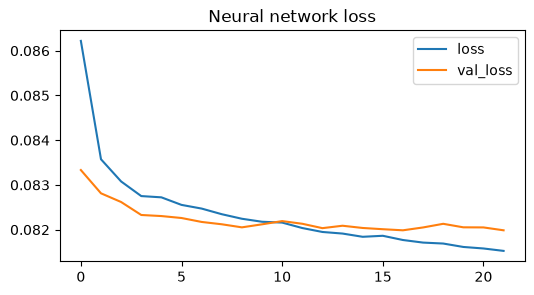

In [7]:
EPOCHS = 2 if QUICK_RUN else 30
BATCH_SIZE = 512
HIDDEN_UNITS = [64, 32]
DROPOUT = 0.3
VALIDATION_FRACTION = 0.2
PATIENCE = 5

scaler = StandardScaler().fit(X_train)


def nn_inputs(frame: pd.DataFrame) -> np.ndarray:
    return np.nan_to_num(scaler.transform(frame))


keras.utils.set_random_seed(RANDOM_STATE)
nn = keras.Sequential([
    keras.Input(shape=(len(feature_names),)),
    layers.Dense(HIDDEN_UNITS[0], activation='relu'),
    layers.Dropout(DROPOUT),
    layers.Dense(HIDDEN_UNITS[1], activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])
nn.compile(optimizer='adam', loss='mse')
history = nn.fit(
    nn_inputs(X_train), y_train, validation_split=VALIDATION_FRACTION, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)],
    verbose=0,
)
pd.DataFrame(history.history).plot(figsize=(6, 3), title='Neural network loss');

### 3-2 LightGBM 與隨機森林

兩個決策樹模型都能直接處理缺值。

In [8]:
N_TREES = 50 if QUICK_RUN else 300

lgbm = LGBMRegressor(
    n_estimators=N_TREES, learning_rate=0.03, num_leaves=31, min_child_samples=200,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1,
).fit(X_train, y_train)

forest = RandomForestRegressor(
    n_estimators=N_TREES, min_samples_leaf=200, max_features=0.5, n_jobs=-1, random_state=RANDOM_STATE,
).fit(X_train, y_train)

LightGBM 認為哪些特徵比較重要：

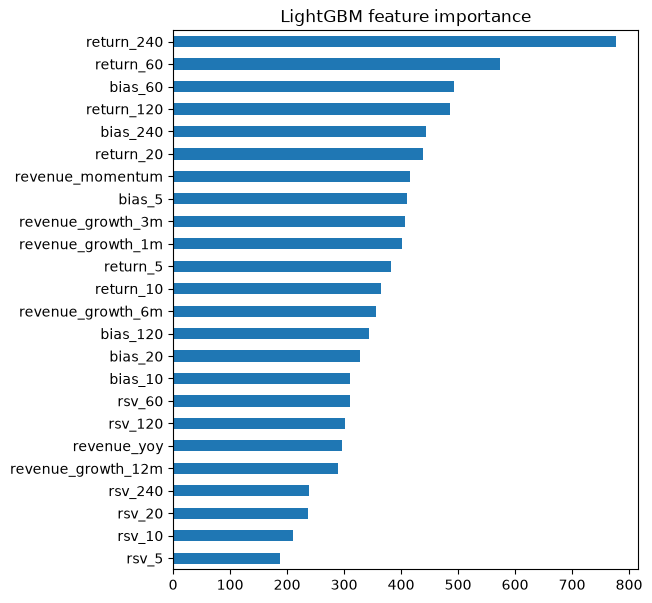

In [9]:
pd.Series(lgbm.feature_importances_, index=feature_names).sort_values().plot.barh(
    figsize=(6, 7), title='LightGBM feature importance');

## 4. 集成學習（Ensemble）

三個模型的預測尺度不同，所以先各自轉成「同一天內的排名」，再平均。

In [10]:
predictions = pd.DataFrame({
    'nn': nn.predict(nn_inputs(clipped), verbose=0).ravel(),
    'lightgbm': lgbm.predict(clipped),
    'random_forest': forest.predict(clipped),
}, index=clipped.index)

model_ranks = predictions.groupby(level='datetime').rank(pct=True)
model_ranks['ensemble'] = model_ranks.mean(axis=1)
model_ranks.tail()

nn  lightgbm  random_forest  ensemble
datetime   instrument                                             
2018-12-10 9933        0.564899  0.826325       0.906764  0.765996
           9934        0.202925  0.641682       0.603291  0.482633
           9938        0.054845  0.153565       0.191956  0.133455
           9945        0.658135  0.765996       0.720293  0.714808
           9958        0.917733  0.681901       0.363803  0.654479

## 5. 回測：每月買排名最高的 20 檔

只回測測試期間（模型沒看過的資料）。

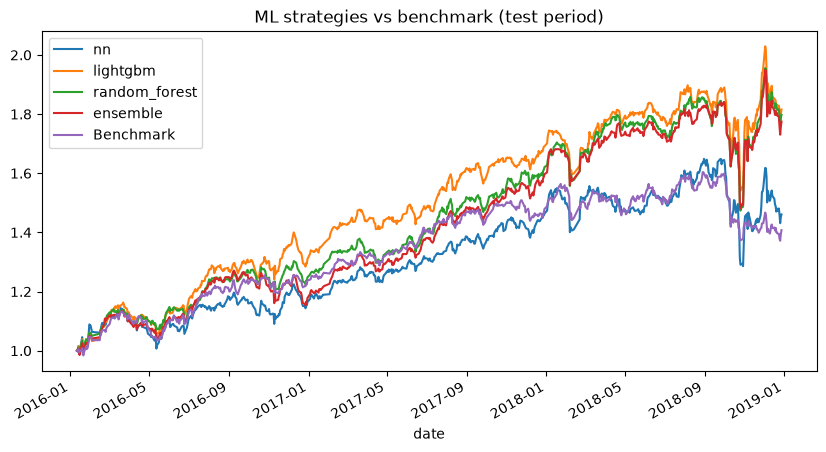

In [11]:
def backtest(score: pd.Series, name: str):
    wide = FinlabDataFrame(score.unstack('instrument'))
    position = wide.loc[TEST_START:].is_largest(N_STOCKS)
    return sim(position, name=name)


reports = {name: backtest(model_ranks[name], name) for name in model_ranks.columns}

curves = pd.DataFrame({name: report.creturn for name, report in reports.items()})
benchmark = reports['ensemble'].benchmark.reindex(curves.index)
curves['Benchmark'] = benchmark / benchmark.dropna().iloc[0]
curves.plot(figsize=(10, 5), title='ML strategies vs benchmark (test period)');

In [12]:
pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in reports.items()
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
nn,13.64%,-22.00%,0.74
lightgbm,22.30%,-18.80%,1.21
random_forest,21.89%,-20.70%,1.23
ensemble,21.36%,-19.56%,1.22


## 6. 最新一期的選股

資料最後一個選股日的前 20 名，以及用 `FUND` 元平均分配時，每檔大約可以買幾張（1 張 = 1000 股）。

In [13]:
FUND = 1_000_000
SHARES_PER_LOT = 1000

latest_date = model_ranks.index.get_level_values('datetime').max()
latest = model_ranks.xs(latest_date, level='datetime')['ensemble'].nlargest(N_STOCKS)

categories = data.get('security_categories').set_index('stock_id')
latest_close = data.get('price:收盤價').loc[:latest_date].iloc[-1]

picks = pd.DataFrame({
    'name': categories['name'].reindex(latest.index),
    'score': latest,
    'close': latest_close.reindex(latest.index),
})
picks['lots'] = (FUND / N_STOCKS / picks['close'] / SHARES_PER_LOT).round(2)
print(f'選股日：{latest_date:%Y-%m-%d}')
picks

選股日：2018-12-10


,name,score,close,lots
instrument,,,,
8049,晶采,0.995734,18.80,2.66
1532,勤美,0.991469,34.10,1.47
2458,義隆,0.989640,75.00,0.67
3519,綠能,0.986594,6.14,8.14
2404,漢唐,0.985984,78.80,0.63
2395,研華,0.983547,223.50,0.22
3376,新日興,0.983547,88.00,0.57
4113,聯上,0.978672,11.40,4.39
8150,南茂,0.972578,27.50,1.82


下一個單元，把這份持股清單交給 `finlab.online`，自動計算要下的委託單。